In [3]:
# Step 1 — Import libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
# Step 2 — Load dataset

In [11]:
df = pd.read_csv("pasteurized_milk_shelf_life_dataset.csv")

df.head(10)

,Storage_Temperature_C,Storage_Time_Days,pH,Titratable_Acidity_pct,Microbial_Load_log_CFU_mL,Sensory_Score,Shelf_Life_Status
0,2.73,5.40,6.519,0.163,2.65,8.77,Acceptable
1,3.44,4.24,6.555,0.160,3.04,8.43,Acceptable
2,2.73,9.29,6.391,0.193,3.66,7.66,Acceptable
3,6.59,5.52,6.438,0.185,3.02,8.38,Acceptable
4,6.47,3.31,6.634,0.157,2.84,8.15,Acceptable
5,5.63,6.33,6.408,0.195,3.36,7.08,Acceptable
6,5.34,1.09,6.608,0.146,2.42,9.37,Acceptable
7,4.41,0.52,6.701,0.138,2.16,9.68,Acceptable
8,8.24,12.10,6.131,0.248,4.76,5.97,Spoiled
9,2.78,8.22,6.479,0.197,3.34,7.70,Acceptable


In [13]:
# Step 3 — Understand the dataset

In [15]:
print(df.shape)
print(df.info())
print(df.describe())

(1500, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Storage_Temperature_C      1500 non-null   float64
 1   Storage_Time_Days          1500 non-null   float64
 2   pH                         1500 non-null   float64
 3   Titratable_Acidity_pct     1500 non-null   float64
 4   Microbial_Load_log_CFU_mL  1500 non-null   float64
 5   Sensory_Score              1500 non-null   float64
 6   Shelf_Life_Status          1500 non-null   object 
dtypes: float64(6), object(1)
memory usage: 82.2+ KB
None
       Storage_Temperature_C  Storage_Time_Days           pH  \
count            1500.000000        1500.000000  1500.000000   
mean                5.995080           7.506393     6.401122   
std                 2.352092           4.340732     0.163285   
min                 2.040000           0.000000     6.002000   
25

In [17]:
# Step 4 — Check missing values and duplicates

In [19]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Storage_Temperature_C        0
Storage_Time_Days            0
pH                           0
Titratable_Acidity_pct       0
Microbial_Load_log_CFU_mL    0
Sensory_Score                0
Shelf_Life_Status            0
dtype: int64
Duplicates: 0


In [21]:
# Step 5 — Check target distribution

Shelf_Life_Status
Acceptable    979
Spoiled       521
Name: count, dtype: int64


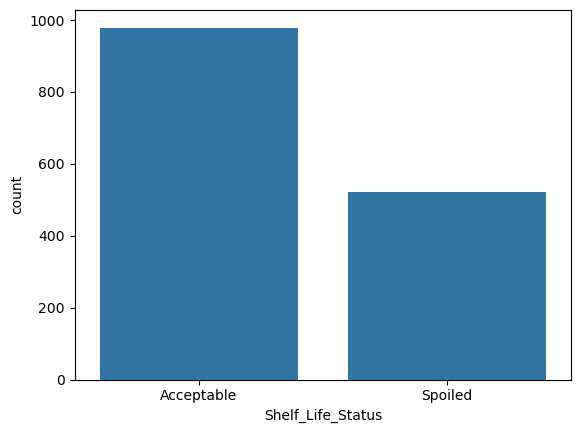

In [23]:
print(df["Shelf_Life_Status"].value_counts())

sns.countplot(x="Shelf_Life_Status", data=df)
plt.show()

In [25]:
# Step 6 — Correlation between numerical variables

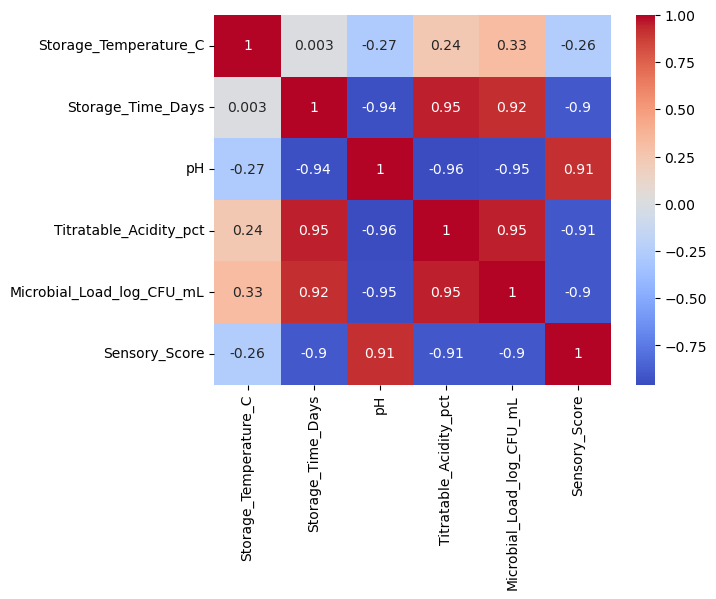

In [27]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [29]:
# Step 7 — Select features and target

In [31]:
X = df.drop("Shelf_Life_Status", axis=1)
y = df["Shelf_Life_Status"]

In [33]:
# Step 8 — Train-test split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1200, 6)
(300, 6)


In [37]:
# Step 9 — Logistic Regression

In [39]:
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9533333333333334
              precision    recall  f1-score   support

  Acceptable       0.95      0.98      0.96       192
     Spoiled       0.96      0.91      0.93       108

    accuracy                           0.95       300
   macro avg       0.96      0.94      0.95       300
weighted avg       0.95      0.95      0.95       300



In [41]:
# Step 10 — Decision Tree

In [43]:
model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9966666666666667
              precision    recall  f1-score   support

  Acceptable       0.99      1.00      1.00       192
     Spoiled       1.00      0.99      1.00       108

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [45]:
# Step 11 — Random Forest

In [47]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9966666666666667
              precision    recall  f1-score   support

  Acceptable       0.99      1.00      1.00       192
     Spoiled       1.00      0.99      1.00       108

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [49]:
# Step 12 — Compare models

In [51]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.953333
1        Decision Tree  0.996667
2        Random Forest  0.996667


In [53]:
# Step 13 — Confusion Matrix

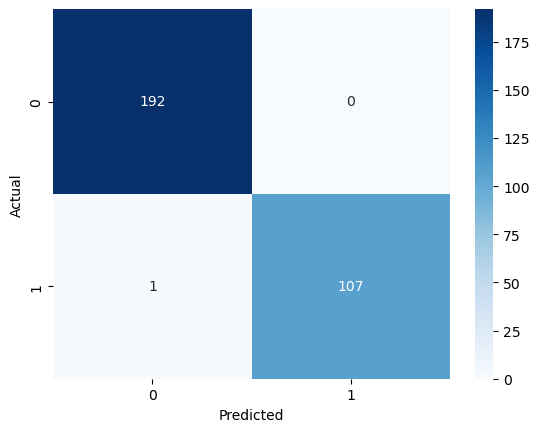

In [55]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [57]:
# Step 14 — Feature Importance

Titratable_Acidity_pct       0.441776
pH                           0.182669
Microbial_Load_log_CFU_mL    0.154118
Storage_Time_Days            0.145619
Sensory_Score                0.068628
Storage_Temperature_C        0.007190
dtype: float64


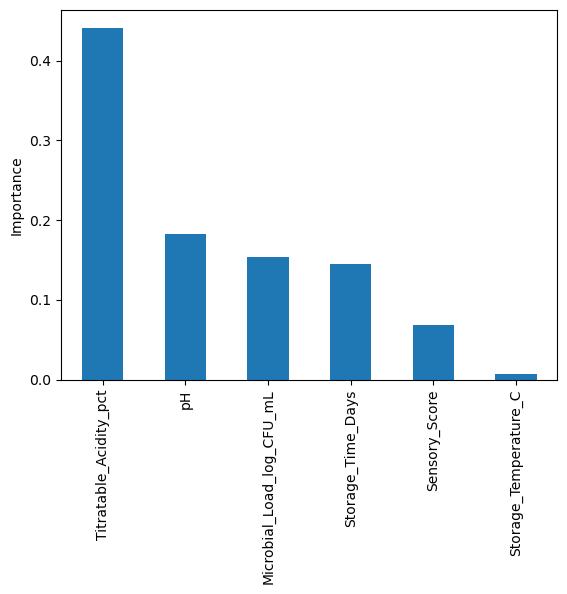

In [59]:
importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind="bar")
plt.ylabel("Importance")
plt.show()